Importy

In [1]:
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.metrics import classification_report_imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN

from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve, average_precision_score, f1_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

Wczytanie Danych

In [2]:
dataset = fetch_openml(data_id=40536, as_frame=True, parser='auto')
df = dataset.frame

1.1. Analiza Danych - Podstawowe informacje o zbiorze

In [3]:
print(df.columns, "\n")

df.info()

Index(['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age',
       'race', 'race_o', 'samerace',
       ...
       'expected_num_matches', 'd_expected_happy_with_sd_people',
       'd_expected_num_interested_in_me', 'd_expected_num_matches', 'like',
       'guess_prob_liked', 'd_like', 'd_guess_prob_liked', 'met', 'match'],
      dtype='str', length=121) 

<class 'pandas.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 121 entries, has_null to match
dtypes: category(62), float64(57), int64(2)
memory usage: 4.3 MB


In [4]:
print(dataset.DESCR)

**Author**: Ray Fisman and Sheena Iyengar  
**Source**: [Columbia Business School](http://www.stat.columbia.edu/~gelman/arm/examples/speed.dating/) - 2004  
**Please cite**: None  

This data was gathered from participants in experimental speed dating events from 2002-2004. During the events, the attendees would have a four-minute "first date" with every other participant of the opposite sex. At the end of their four minutes, participants were asked if they would like to see their date again. They were also asked to rate their date on six attributes: Attractiveness, Sincerity, Intelligence, Fun, Ambition, and Shared Interests. The dataset also includes questionnaire data gathered from participants at different points in the process. These fields include: demographics, dating habits, self-perception across key attributes, beliefs on what others find valuable in a mate, and lifestyle information. 

### Attribute Information
```
 * gender: Gender of self  
 * age: Age of self  
 * age_o: 

Top 10 kolumn z brakującymi wartościami

In [5]:
print(df.isnull().sum().sort_values(ascending=False).head(10))

expected_num_interested_in_me    6578
expected_num_matches             1173
shared_interests_o               1076
shared_interests_partner         1067
ambitous_o                        722
ambition_partner                  712
met                               375
funny_o                           360
funny_partner                     350
guess_prob_liked                  309
dtype: int64


One-Hot Encoding

In [6]:
df_encoded = pd.get_dummies(df, drop_first=True)

Siła korelacji z targetem

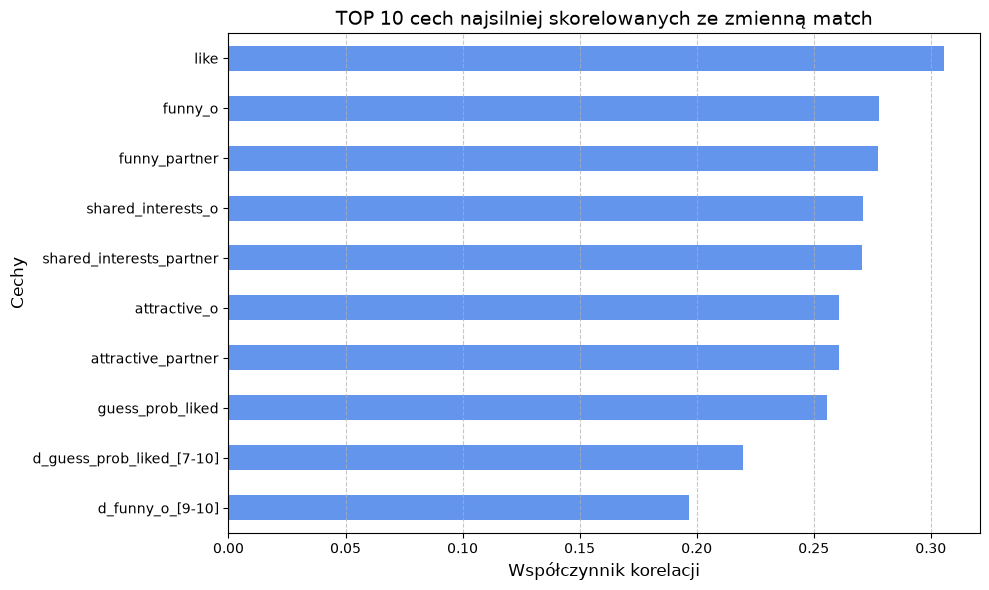

In [7]:
target = 'match_1'

new_blue = '#6495ED' 

if target in df_encoded.columns:
    correlations = df_encoded.corr()[target]

    top_correlations_abs = correlations.drop(target).abs().sort_values(ascending=False).head(10)

    top_features = correlations[top_correlations_abs.index].sort_values()

    plt.figure(figsize=(10, 6))

    colors = [new_blue if x > 0 else "red" for x in top_features]
    top_features.plot(kind='barh', color=colors)
    
    plt.title(f'TOP 10 cech najsilniej skorelowanych ze zmienną match', fontsize=14)
    plt.xlabel('Współczynnik korelacji', fontsize=12)
    plt.ylabel('Cechy', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Błąd: Zmienna '{target}' nie istnieje w przetworzonym zbiorze danych.")
    print(f"Dostępne kolumny to m.in.: {list(df_encoded.columns[:20])}")

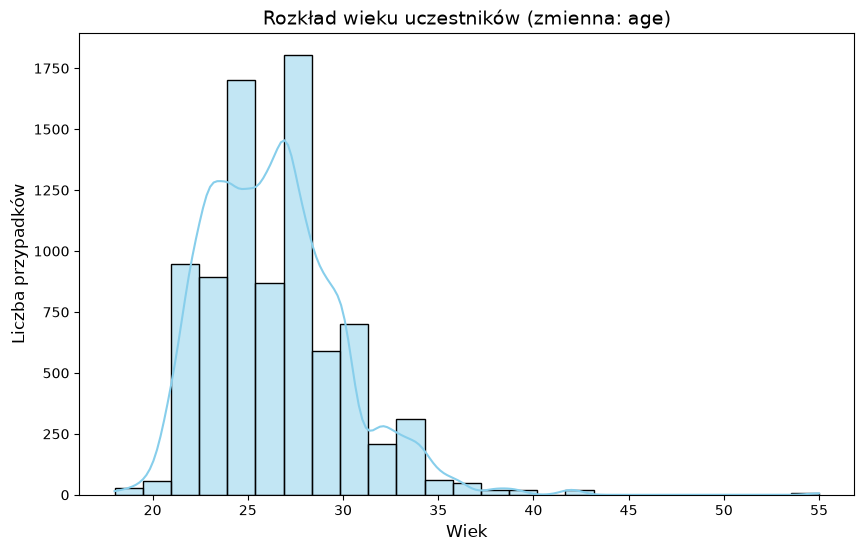

In [8]:
if 'age' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='age', bins=25, kde=True, color='skyblue')
    plt.title('Rozkład wieku uczestników (zmienna: age)', fontsize=14)
    plt.xlabel('Wiek', fontsize=12)
    plt.ylabel('Liczba przypadków', fontsize=12)
    plt.show()

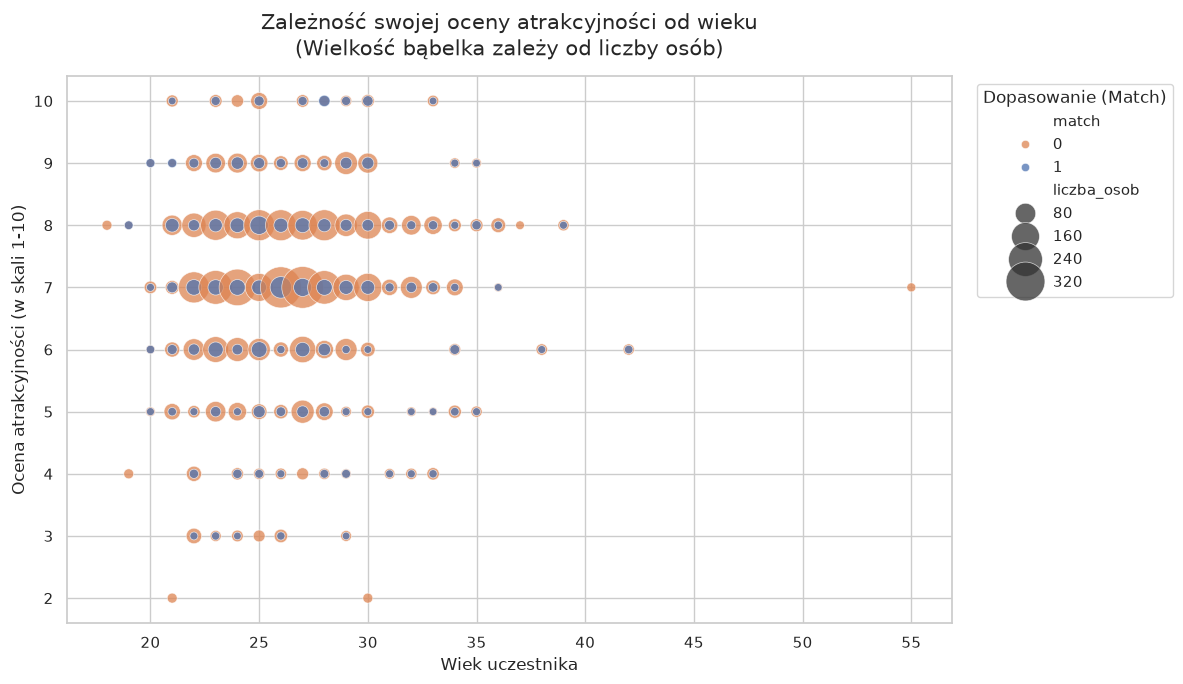

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

col_attr = 'attractive' if 'attractive' in df.columns else 'attr'

if all(col in df.columns for col in ['age', col_attr, 'match']):
    df_grouped = df.groupby(['age', col_attr, 'match']).size().reset_index(name='liczba_osob')
    plt.figure(figsize=(12, 7))

    color_match = sns.color_palette("deep")[0]   
    color_no_match = sns.color_palette("deep")[1]

    safe_palette = {
        0: color_no_match, 1: color_match,
        '0': color_no_match, '1': color_match
    }
    
    sns.scatterplot(
        data=df_grouped, 
        x='age', 
        y=col_attr, 
        hue='match', 
        size='liczba_osob',
        sizes=(30, 900),  
        alpha=0.75,       
        palette=safe_palette,
        edgecolor="white", 
        linewidth=0.5
    )

    plt.title('Zależność swojej oceny atrakcyjności od wieku\n(Wielkość bąbelka zależy od liczby osób)', fontsize=15, pad=15)
    plt.xlabel('Wiek uczestnika', fontsize=12)
    plt.ylabel('Ocena atrakcyjności (w skali 1-10)', fontsize=12)
    
    plt.legend(title='Dopasowanie (Match)', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
else:
    print("Brak wymaganych kolumn w zbiorze danych.")

Wnioski z Analizy Danych

Widać, że w badaniu wzięli udział przede wszystkim ludzie młodzi (przedział wiekowy: 20-30 lat). 
Mamy też jeden outliery w age: Jedna osoba badana ma 55 lat.

Ogółem ludzie oceniali swoją urodę nawzajem całkiem pozytywnie (średnia ocena to mniej więcej 7/10) ale widać też, że uroda to nie wszystko. 
Mieliśmy przypadki, w których 10/10 w attractive nie oznacza matchu.

Ludzie bardziej cenią sobie to czy ktoś jest zabawny i czy mają jakieś wspólne zainteresowania.

1.2. Przygotowanie Danych

In [10]:
# Usuwamy dane żeby nie doprowadzić do wycieku danych
leakage_cols_openml = [
    'decision', 'decision_o', 'match', 'match_1',
    'like', 'guess_prob_liked', 'met',
    
    'attractive_partner', 'sincere_partner', 'intelligence_partner', 
    'funny_partner', 'ambition_partner', 'shared_interests_partner',
    
    'attractive_o', 'sinsere_o', 'sincere_o', 'intelligence_o', 
    'funny_o', 'ambitous_o', 'ambition_o', 'shared_interests_o'
]

cols_to_drop_existing = [col for col in leakage_cols_openml if col in df.columns]

X = df.drop(columns=cols_to_drop_existing)

target_col = 'match_1' if 'match_1' in df.columns else 'match'
y = df[target_col]

print(f"Liczba cech PRZED usunięciem: {df.shape[1]}")
print(f"Liczba cech PO usunięciu: {X.shape[1]}")
print(f"Usunięto {df.shape[1] - X.shape[1]} kolumn stanowiących wyciek danych.")

Liczba cech PRZED usunięciem: 121
Liczba cech PO usunięciu: 105
Usunięto 16 kolumn stanowiących wyciek danych.


In [11]:
# 1. Tworzenie "odcisku palca" (ID) użytkownika
profile_features = ['age', 'gender', 'field', 'imprace', 'imprelig', 'goal', 'date', 'go_out']

available_profile_features = [col for col in profile_features if col in X.columns]

def generate_fingerprint(row):
    profile_string = "_".join([str(x) for x in row[available_profile_features]])
    
    return hashlib.md5(profile_string.encode('utf-8')).hexdigest()

user_ids = X.apply(generate_fingerprint, axis=1)

print(f"Wygenerowano odciski palców. Unikalnych użytkowników w zbiorze: {user_ids.nunique()}")

print("\nPrzed OHE:", X.shape)

X_encoded = pd.get_dummies(X, drop_first=True)

print("Po OHE:   ", X_encoded.shape)

Wygenerowano odciski palców. Unikalnych użytkowników w zbiorze: 449

Przed OHE: (8378, 105)
Po OHE:    (8378, 424)


In [12]:
# Podział na zbiór treeningowy i testowy

N_TEST_SAMPLES = 5

user_counts = user_ids.value_counts()

valid_users = user_counts[user_counts >= N_TEST_SAMPLES].index

valid_mask = user_ids.isin(valid_users)
X_valid = X_encoded[valid_mask]
y_valid = y[valid_mask]
user_ids_valid = user_ids[valid_mask]

test_indices = user_ids_valid.groupby(user_ids_valid).sample(n=N_TEST_SAMPLES, random_state=42).index

train_indices = X_valid.index.difference(test_indices)

X_train = X_valid.loc[train_indices]
X_test = X_valid.loc[test_indices]
y_train = y_valid.loc[train_indices]
y_test = y_valid.loc[test_indices]

print("--- Podsumowanie podziału ---")
print(f"Liczba wierszy w zbiorze treningowym (X_train): {X_train.shape[0]}")
print(f"Liczba wierszy w zbiorze testowym (X_test): {X_test.shape[0]}")
print(f"Liczba użytkowników wziętych pod uwagę: {len(valid_users)}")

--- Podsumowanie podziału ---
Liczba wierszy w zbiorze treningowym (X_train): 6133
Liczba wierszy w zbiorze testowym (X_test): 2245
Liczba użytkowników wziętych pod uwagę: 449


Uzupełnienie braków

In [13]:
print("Liczba braków w X_train PRZED imputacją:", X_train.isnull().sum().sum())
print("Liczba braków w X_test PRZED imputacją:", X_test.isnull().sum().sum())

imputer = SimpleImputer(strategy='median')

X_train_imputed_array = imputer.fit_transform(X_train)

X_test_imputed_array = imputer.transform(X_test)

X_train = pd.DataFrame(X_train_imputed_array, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed_array, columns=X_test.columns, index=X_test.index)

print("\nLiczba braków w X_train PO imputacji:", X_train.isnull().sum().sum())
print("Liczba braków w X_test PO imputacji:", X_test.isnull().sum().sum())

Liczba braków w X_train PRZED imputacją: 8419
Liczba braków w X_test PRZED imputacją: 2963

Liczba braków w X_train PO imputacji: 0
Liczba braków w X_test PO imputacji: 0


Tworzenie nowych cech

In [14]:
def add_custom_features(dataset):
    df_new = dataset.copy()
    
    # 1. Różnica w atrakcyjności (Oczekiwania vs Samoocena)
    if 'attractive_important' in df_new.columns and 'attractive' in df_new.columns:
        df_new['attr_diff'] = abs(df_new['attractive_important'] - df_new['attractive'])
        
    # 2. Różnica wieku (bardzo użyteczna cecha w aplikacjach randkowych)
    if 'age' in df_new.columns and 'age_o' in df_new.columns:
        df_new['age_diff'] = abs(df_new['age'] - df_new['age_o'])
        
    # 3. Zsumowanie znaczenia religii i rasy (jak bardzo ktoś jest "konserwatywny" w wyborze)
    if 'imprelig' in df_new.columns and 'imprace' in df_new.columns:
        df_new['importance_traditional'] = df_new['imprelig'] + df_new['imprace']
        
    return df_new

X_train = add_custom_features(X_train)
X_test = add_custom_features(X_test)

print(f"Liczba cech po inżynierii danych w X_train: {X_train.shape[1]}")
print(f"Liczba cech po inżynierii danych w X_test: {X_test.shape[1]}")

Liczba cech po inżynierii danych w X_train: 426
Liczba cech po inżynierii danych w X_test: 426


Standaryzacja danych

In [15]:
scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train)

X_test_scaled_array = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled_array, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled_array, columns=X_test.columns, index=X_test.index)

Naiwne Predyktory

In [16]:
print("=== PREDYKTOR WIĘKSZOŚCIOWY ===")
dummy_majority = DummyClassifier(strategy='prior')
dummy_majority.fit(X_train, y_train)

y_pred_majority = dummy_majority.predict(X_test)

print(classification_report_imbalanced(y_test, y_pred_majority))


print("\n=== PREDYKTOR LOSOWY ===")
dummy_random = DummyClassifier(strategy='stratified', random_state=42)
dummy_random.fit(X_train, y_train)

y_pred_random = dummy_random.predict(X_test)

print(classification_report_imbalanced(y_test, y_pred_random))

=== PREDYKTOR WIĘKSZOŚCIOWY ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      1.00      0.00      0.91      0.00      0.00      1876
          1       0.00      0.00      1.00      0.00      0.00      0.00       369

avg / total       0.70      0.84      0.16      0.76      0.00      0.00      2245


=== PREDYKTOR LOSOWY ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.84      0.84      0.21      0.84      0.42      0.19      1876
          1       0.20      0.21      0.84      0.21      0.42      0.16       369

avg / total       0.74      0.74      0.31      0.74      0.42      0.18      2245



/home/micha/ML_Lab06/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Podstawowe modele

a) Regresja logistyczna

In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

y_proba_log = log_reg.predict_proba(X_test)[:, 1] 

print("=== REGRESJA LOGISTYCZNA (Model Bazowy) ===")
print(classification_report_imbalanced(y_test, y_pred))


=== REGRESJA LOGISTYCZNA (Model Bazowy) ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.94      0.38      0.91      0.59      0.37      1876
          1       0.54      0.38      0.94      0.44      0.59      0.33       369

avg / total       0.83      0.84      0.47      0.83      0.59      0.37      2245



Model radzi sobie zauważalnie gorzej z predykcjami dla klasy mniejszościowej, niż z predykowanie klasy większościowej. Nauczył się, że przypadków matchu jest mniej niż jego braku. Nadal jednak tylko w 54% przewidział, że nastąpił match (odrobinę lepiej niż rzut monetą). Najgorsza jest jednak czułość (Recall) na poziomie 38%. To oznacza, że wyłapał jedynie 38% potencjalnych par.

1.4. Resampling

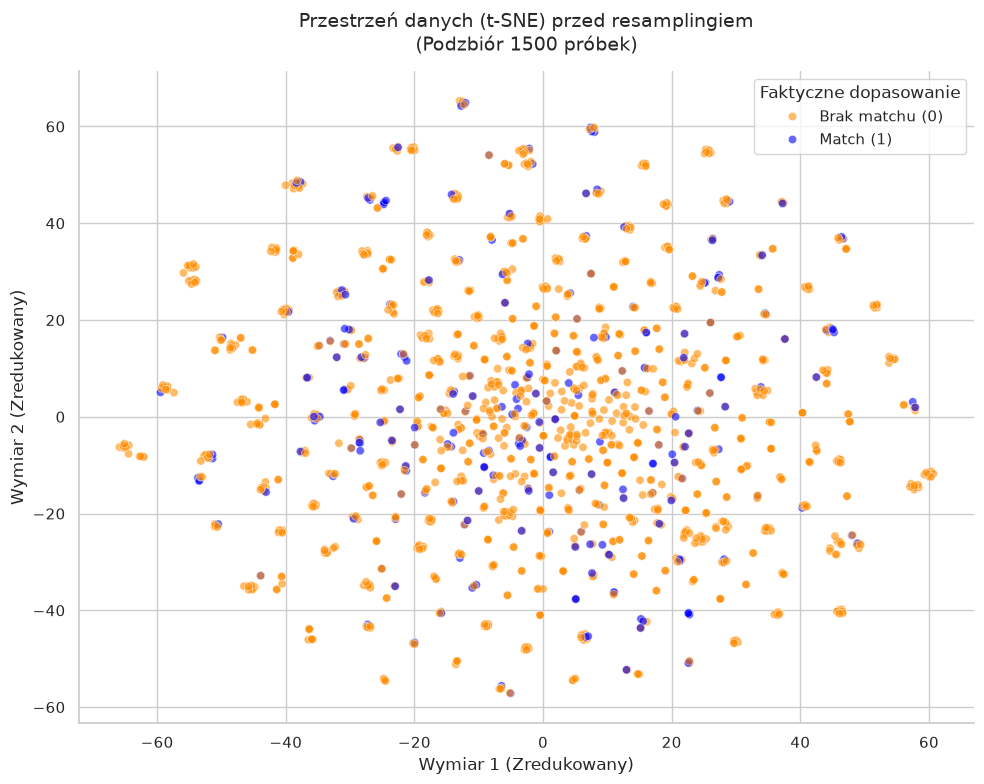

In [18]:
sample_size = 1500
n_samples = min(sample_size, len(X_train))

X_train_sample = X_train.sample(n=n_samples, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_train_sample)

df_tsne = pd.DataFrame(data=X_tsne, columns=['Dim 1', 'Dim 2'])

df_tsne['Match'] = y_train_sample.values.astype(int) 

df_tsne['Decyzja'] = df_tsne['Match'].map({0: 'Brak matchu (0)', 1: 'Match (1)'})

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_tsne,
    x='Dim 1',
    y='Dim 2',
    hue='Decyzja',
    palette={'Brak matchu (0)': 'darkorange', 'Match (1)': 'blue'},
    alpha=0.6,
    edgecolor='white',
    linewidth=0.5
)

plt.title('Przestrzeń danych (t-SNE) przed resamplingiem\n(Podzbiór 1500 próbek)', fontsize=14, pad=15)
plt.xlabel('Wymiar 1 (Zredukowany)', fontsize=12)
plt.ylabel('Wymiar 2 (Zredukowany)', fontsize=12)
plt.legend(title='Faktyczne dopasowanie', loc='best')

sns.despine()
plt.tight_layout()
plt.show()

In [19]:
# SMOTE
print("Rozkład klas PRZED resamplingiem w zbiorze treningowym:")
print(y_train.value_counts())
print("-" * 40)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Rozkład po SMOTE:")
print(y_train_smote.value_counts())
print("-" * 40)

# RandomUnderSampler + SMOTE
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
over = SMOTE(sampling_strategy=1.0, random_state=42)

pipeline = Pipeline(steps=[('under', under), ('over', over)])
X_train_pipe, y_train_pipe = pipeline.fit_resample(X_train, y_train)
print("Rozkład po Pipeline:")
print(y_train_pipe.value_counts())
print("-" * 40)

# SMOTE + ENN
smote_enn = SMOTEENN(random_state=42)
X_train_sme, y_train_sme = smote_enn.fit_resample(X_train, y_train)
print("Rozkład po SMOTE+ENN:")
print(y_train_sme.value_counts())

Rozkład klas PRZED resamplingiem w zbiorze treningowym:
match
0    5122
1    1011
Name: count, dtype: int64
----------------------------------------
Rozkład po SMOTE:
match
0    5122
1    5122
Name: count, dtype: int64
----------------------------------------
Rozkład po Pipeline:
match
0    2022
1    2022
Name: count, dtype: int64
----------------------------------------
Rozkład po SMOTE+ENN:
match
1    4767
0    3155
Name: count, dtype: int64


In [20]:
def evaluate_resampling_method(X_resampled, y_resampled, method_name):
    print(f"Metoda: {method_name}")
    
    model = LogisticRegression(max_iter=1000, random_state=42)

    model.fit(X_resampled, y_resampled)
    
    y_pred = model.predict(X_test)

    print(classification_report_imbalanced(y_test, y_pred))

evaluate_resampling_method(X_train_smote, y_train_smote, "SMOTE")
evaluate_resampling_method(X_train_pipe, y_train_pipe, "Potok (Under + SMOTE)")
evaluate_resampling_method(X_train_sme, y_train_sme, "Hybryda (SMOTE + ENN)")

Metoda: SMOTE
                   pre       rec       spe        f1       geo       iba       sup

          0       0.91      0.80      0.61      0.85      0.70      0.50      1876
          1       0.37      0.61      0.80      0.46      0.70      0.48       369

avg / total       0.82      0.77      0.64      0.79      0.70      0.49      2245

Metoda: Potok (Under + SMOTE)
                   pre       rec       spe        f1       geo       iba       sup

          0       0.91      0.76      0.64      0.83      0.70      0.49      1876
          1       0.34      0.64      0.76      0.45      0.70      0.48       369

avg / total       0.82      0.74      0.66      0.77      0.70      0.49      2245

Metoda: Hybryda (SMOTE + ENN)
                   pre       rec       spe        f1       geo       iba       sup

          0       0.92      0.70      0.69      0.80      0.70      0.49      1876
          1       0.31      0.69      0.70      0.43      0.70      0.48       369

avg /

Widać ogromny wzrost jakości (szczególnie w metryce recall, dla każdej z 3 metod wzrosło do >60%).

Spadła natomiast nam poziom precyzji. To nie musi byc wcale wada. Po prostu dajemy użytkownikowi więcej opcji, z których niektóre okażą się nietrafione. To kompromis, na który trzeba było pójść w tak prostym modelu.

1.5. Ensemble

In [21]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

print("=== 1. RANDOM FOREST ===")
rf_weighted = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_weighted.fit(X_train, y_train)

y_pred_rf = rf_weighted.predict(X_test)
y_proba_rf = rf_weighted.predict_proba(X_test)[:, 1]
print(classification_report_imbalanced(y_test, y_pred_rf))


print("\n=== 2. BALANCED RANDOM FOREST ===")
brf = BalancedRandomForestClassifier(random_state=42, n_estimators=100)
brf.fit(X_train, y_train)

y_pred_brf = brf.predict(X_test)
y_proba_brf = brf.predict_proba(X_test)[:, 1]
print(classification_report_imbalanced(y_test, y_pred_brf))

=== 1. RANDOM FOREST ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.87      0.96      0.30      0.92      0.54      0.31      1876
          1       0.61      0.30      0.96      0.40      0.54      0.27       369

avg / total       0.83      0.85      0.41      0.83      0.54      0.30      2245


=== 2. BALANCED RANDOM FOREST ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.90      0.87      0.53      0.89      0.68      0.47      1876
          1       0.44      0.53      0.87      0.48      0.68      0.44       369

avg / total       0.83      0.81      0.58      0.82      0.68      0.47      2245



Lasy Losowe, a szczególnie Balanced Random Forest osiągneły wyższy wynik F1-Score niż Regresja logistyczna. Oznacza to, że są to modele lepiej zbalansowane. Znacznie skuteczniej predykują prawdzie matche.

ROC i Pre-Rec

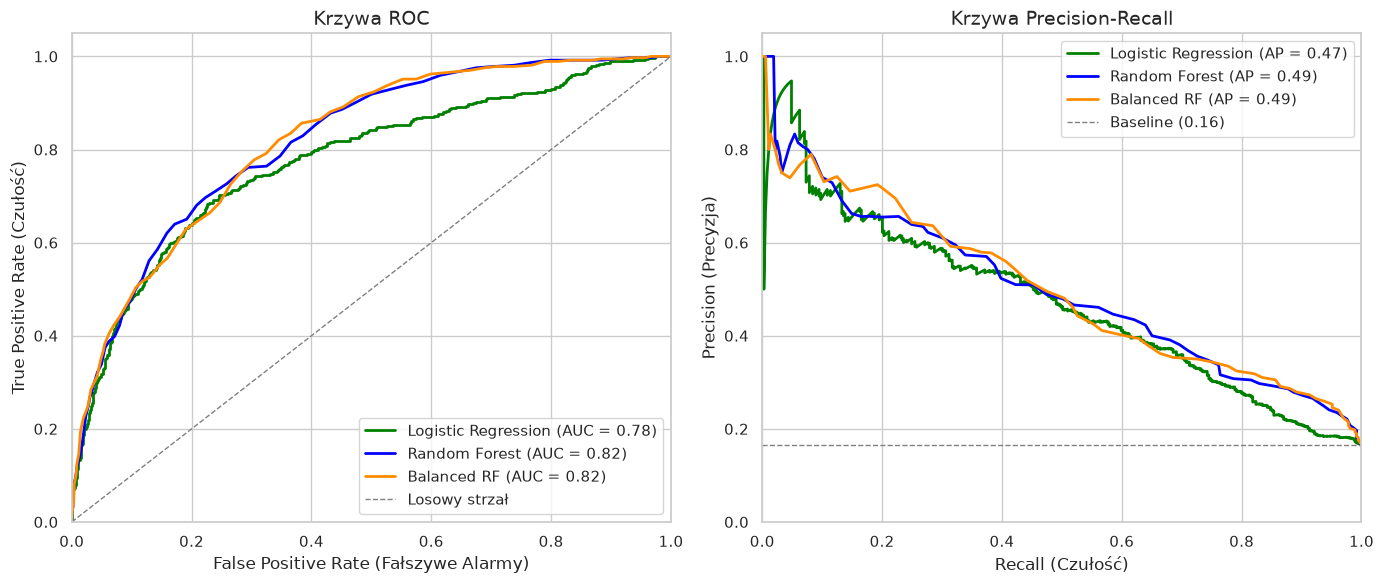

In [22]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_brf, tpr_brf, _ = roc_curve(y_test, y_proba_brf)
roc_auc_brf = auc(fpr_brf, tpr_brf)

plt.plot(fpr_log, tpr_log, color='green', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_brf, tpr_brf, color='darkorange', lw=2, label=f'Balanced RF (AUC = {roc_auc_brf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Losowy strzał')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Fałszywe Alarmy)', fontsize=12)
plt.ylabel('True Positive Rate (Czułość)', fontsize=12)
plt.title('Krzywa ROC', fontsize=14)
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)

precision_log, recall_log, _ = precision_recall_curve(y_test, y_proba_log)
ap_log = average_precision_score(y_test, y_proba_log)

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
ap_rf = average_precision_score(y_test, y_proba_rf)

precision_brf, recall_brf, _ = precision_recall_curve(y_test, y_proba_brf)
ap_brf = average_precision_score(y_test, y_proba_brf)

plt.plot(recall_log, precision_log, color='green', lw=2, label=f'Logistic Regression (AP = {ap_log:.2f})')
plt.plot(recall_rf, precision_rf, color='blue', lw=2, label=f'Random Forest (AP = {ap_rf:.2f})')
plt.plot(recall_brf, precision_brf, color='darkorange', lw=2, label=f'Balanced RF (AP = {ap_brf:.2f})')

baseline = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [baseline, baseline], color='gray', lw=1, linestyle='--', label=f'Baseline ({baseline:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Czułość)', fontsize=12)
plt.ylabel('Precision (Precyzja)', fontsize=12)
plt.title('Krzywa Precision-Recall', fontsize=14)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

Krzywa Precision-Recall jest lepszym wyborem w naszym wypadku ponieważ krzywa ROC bierze pod uwagę True Negatives (czyli pary, które do siebie nie pasowały, co zgadł algorytm). Jest to u nas klasa większościowa więc model łatwo je zgaduje, co sztucznie pompuje mu wynik.

Na krzywej Precision-Recallskupiamy się wyłącznie na klasie pozytywnej, pokazuje namże model często myli się przy wskazywaniu matchu.

Jakie cechy były najważniejsze w Balanced RF?

/tmp/ipykernel_2057/1961655638.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ważność', y='Cecha', data=top_features, palette='mako')


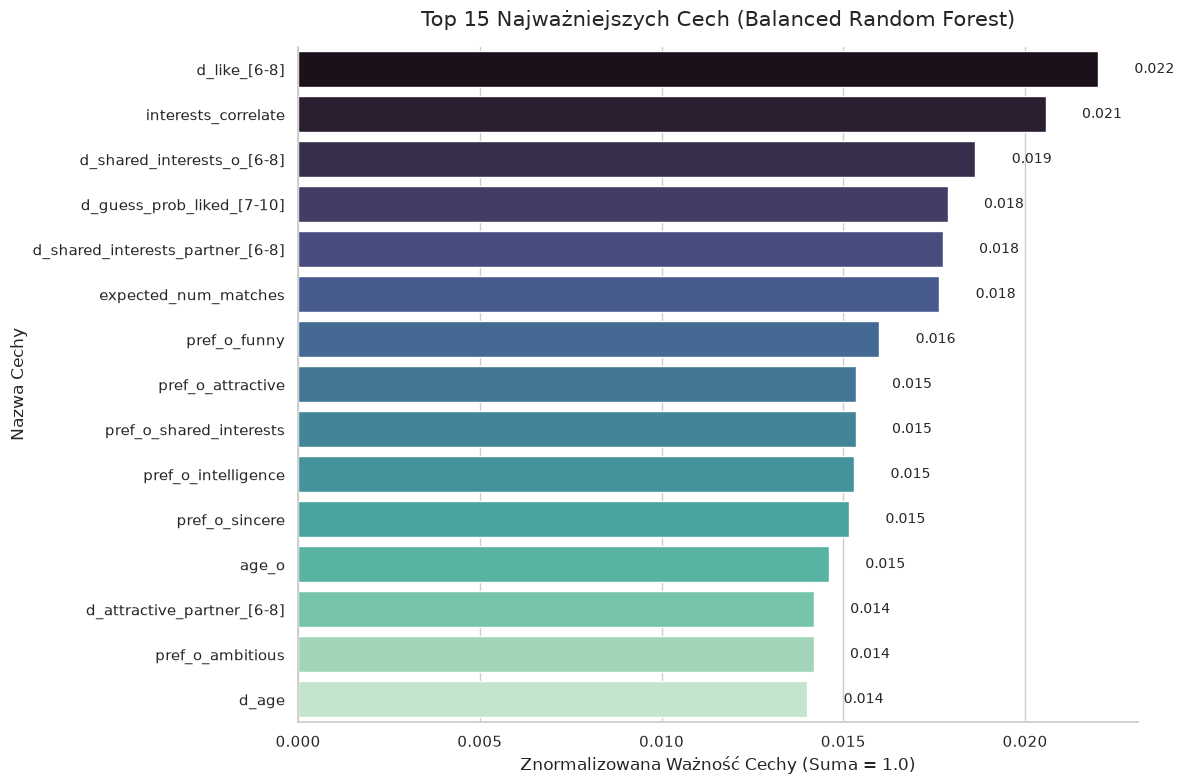

In [23]:
importances = brf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Cecha': X_train.columns,
    'Ważność': importances
}).sort_values(by='Ważność', ascending=False)

top_features = feature_importance_df.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Ważność', y='Cecha', data=top_features, palette='mako')

plt.title('Top 15 Najważniejszych Cech (Balanced Random Forest)', fontsize=15, pad=15)
plt.xlabel('Znormalizowana Ważność Cechy (Suma = 1.0)', fontsize=12)
plt.ylabel('Nazwa Cechy', fontsize=12)

for index, value in enumerate(top_features['Ważność']):
    plt.text(value + 0.001, index, f'{value:.3f}', va='center', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

Widać podobieństwo do wykresu cech skorelowanych z matchem

2. Kalibracja modeli i macierz kosztów

2.1. Metryki rekomendacyjne

In [24]:
sorted_indices = np.argsort(y_proba_brf)[::-1]
y_true_sorted = y_test.values[sorted_indices]

def precision_at_k(y_true, k):
    return sum(y_true[:k]) / k

def mrr(y_true):
    for i, val in enumerate(y_true):
        if val == 1:
            return 1.0 / (i + 1)
    return 0.0

print("=== METRYKI REKOMENDACYJNE ===")
print(f"Precision@10: {precision_at_k(y_true_sorted, 10) * 100:.1f}%")
print(f"Precision@50: {precision_at_k(y_true_sorted, 50) * 100:.1f}%")
print(f"MRR: {mrr(y_true_sorted):.4f}")

=== METRYKI REKOMENDACYJNE ===
Precision@10: 80.0%
Precision@50: 74.0%
MRR: 1.0000


Są to lepsze wskaźniki od globalnych dla naszego modelu ponieważ aplikacje randkowe nie pokazują wszystkich potencjalnych partnerów na raz użytkownikowi, tylko robią to sekwencyjnie.

2.2. Model Romantyczny

In [50]:
romantic_weights = {0: 1, 1: 200} 

rf_romantic = RandomForestClassifier(
    class_weight=romantic_weights,
    random_state=42,
    n_estimators=100
)
rf_romantic.fit(X_train, y_train)
y_pred_romantic_new = rf_romantic.predict(X_test)

print(classification_report(y_test, y_pred_romantic_new))

              precision    recall  f1-score   support

           0       1.00      0.04      0.07      1876
           1       0.17      1.00      0.29       369

    accuracy                           0.19      2245
   macro avg       0.58      0.52      0.18      2245
weighted avg       0.86      0.19      0.11      2245



Ma on recall=100% ale kosztem tylko 17% precyzji

2.3. Model Biznesowy

In [51]:
VAL_TP = 100 
VAL_FP = -15 
VAL_FN = -40 
VAL_TN = 0   

def calculate_profit(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    return (TP * VAL_TP) + (FP * VAL_FP) + (FN * VAL_FN) + (TN * VAL_TN)

rf_business = BalancedRandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_business.fit(X_train, y_train)

y_proba_business = rf_business.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.0, 1.0, 100)
profits = []

for t in thresholds:
    y_pred_t = (y_proba_business >= t).astype(int)
    profits.append(calculate_profit(y_test.values, y_pred_t))

best_threshold = thresholds[np.argmax(profits)]
max_profit = max(profits)

y_pred_business_final = (y_proba_business >= best_threshold).astype(int)

print(f"Największy zysk uzyskamy przy progu: {best_threshold:.2f}")
print(f"Przewidywany zysk firmy dla tego zbioru testowego: {max_profit} PLN\n")

Największy zysk uzyskamy przy progu: 0.34
Przewidywany zysk firmy dla tego zbioru testowego: 19725 PLN



2.4. Podsumowanie Wyników

In [52]:
profit_romantic_new = calculate_profit(y_test.values, y_pred_romantic_new)

results = {
    "Model": ["Romantyczny", "Biznesowy"],
    "Zysk [PLN]": [profit_romantic_new, max_profit],
    "Threshold": [0.50, best_threshold], 
    "Recall (Czułość)": [
        recall_score(y_test, y_pred_romantic_new), 
        recall_score(y_test, y_pred_business_final)
    ],
    "Precision (Precyzja)": [
        precision_score(y_test, y_pred_romantic_new), 
        precision_score(y_test, y_pred_business_final)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_romantic_new), 
        f1_score(y_test, y_pred_business_final)
    ]
}

df_summary = pd.DataFrame(results)

df_summary['Threshold'] = df_summary['Threshold'].round(2)
df_summary['Recall (Czułość)'] = df_summary['Recall (Czułość)'].round(3)
df_summary['Precision (Precyzja)'] = df_summary['Precision (Precyzja)'].round(3)
df_summary['F1-Score'] = df_summary['F1-Score'].round(3)

display(df_summary)

,Model,Zysk [PLN],Threshold,Recall (Czułość),Precision (Precyzja),F1-Score
0,Romantyczny,9765,0.50,1.00,0.169,0.290
1,Biznesowy,19725,0.34,0.87,0.315,0.463


Model romantyczny jest zdecydowanie bardziej optymistyczny w matchowaniu ludzi. Traci przez to na precyzji ale generalnie da klientowi szansę sprawdzić prawie każdą pasującą do niego osobę.

Model Biznesowy natomiast wyłapuje mniej matchy (choć trzeba przyznać, że recall na poziomie 92% to dalej dobry wynik), jest on bardziej selektywny. Dlatego pozwoli nam zarobić lepsze pieniądze.

To model biznesowy ma lepszą miarę F1-Score, co oznacza, że biorąc pod uwagę po równo recall i precision jest lepszym modele od modelu romantycznego.